# 3. Training the GNN and GAT process model and visualizing its quality

`ProcessModelTrainer` fits `GraphProcessModel` on labelled episodes:

* the **GNN** uses each node's features plus 1-hop and 2-hop neighborhood aggregates;
* the **GAT** learns attention restricted to baseline graph edges and returns a per-episode
  directed attention matrix;
* validation holds out **whole recordings**, so events from one recording never appear in both
  train and validation;
* every epoch records loss and top-1 accuracy for train and validation, and final metrics are
  compared with the untrained transparent ranker (Top-1, Top-3, MRR, NLL).

In [1]:
# If the package is not installed yet (run once, then restart the kernel):
# %pip install "graph-evt-agent[notebooks] @ git+https://github.com/D2718281828nis/Graph-EVT-agent"
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42

In [2]:
from graph_evt_agent import (EVTConfig, GraphConfig, GraphEVTPipeline, EpisodeLabeler,
                             GraphLearningConfig, GraphProcessModel, ProcessModelTrainer,
                             TimeSeriesInput)
from graph_evt_agent.synthetic import make_recording
from graph_evt_agent import visualization as viz

recordings = {f"rec{i:02d}": make_recording(n_events=10, n_channels=6, baseline_size=400,
                                            amplitude=8, gain_jitter=0.8, delay_per_hop=3,
                                            seed=SEED + i)
              for i in range(12)}
annotations = {key: list(zip(rec.event_times, rec.sources)) for key, rec in recordings.items()}
pipeline = GraphEVTPipeline(EVTConfig(baseline_size=400, persistence=3),
                            GraphConfig(method="ar", edge_threshold=0.2, random_state=SEED))
labeler = EpisodeLabeler(pipeline)
values = {key: rec.as_input() for key, rec in recordings.items()}
manual = labeler.label(values, annotations)
pseudo = labeler.label(values)
print("manual:", manual.summary())
print("pseudo:", pseudo.summary())

manual: {'episodes': 120, 'manual': 120, 'pseudo': 0, 'abstained': 0, 'skipped_series': 0}
pseudo: {'episodes': 120, 'manual': 0, 'pseudo': 119, 'abstained': 1, 'skipped_series': 0}


## Train on manual labels (with a progress bar)

In [3]:
trainer = ProcessModelTrainer(
    GraphLearningConfig(hidden_dim=8, epochs=300, learning_rate=0.02, random_state=SEED),
    validation_fraction=0.25, random_state=SEED, verbose=True,
)
report = trainer.train(manual)
pd.DataFrame(report.summary_table()).round(3)

Training GNN/GAT:   0%|          | 0/300 [00:00<?, ?it/s]

Training GNN/GAT:   2%|▏         | 5/300 [00:00<00:06, 44.06it/s, GNN loss 1.512 GAT loss 1.455 | val acc 0.47/0.43]

Training GNN/GAT:   4%|▎         | 11/300 [00:00<00:05, 52.21it/s, GNN loss 1.244 GAT loss 1.176 | val acc 0.40/0.43]

Training GNN/GAT:   6%|▌         | 17/300 [00:00<00:05, 48.96it/s, GNN loss 1.048 GAT loss 1.019 | val acc 0.43/0.50]

Training GNN/GAT:   7%|▋         | 22/300 [00:00<00:05, 47.58it/s, GNN loss 0.952 GAT loss 0.927 | val acc 0.50/0.50]

...

Training GNN/GAT:  96%|█████████▋| 289/300 [00:06<00:00, 48.96it/s, GNN loss 0.206 GAT loss 0.291 | val acc 0.43/0.43]

Training GNN/GAT:  98%|█████████▊| 295/300 [00:06<00:00, 47.74it/s, GNN loss 0.202 GAT loss 0.288 | val acc 0.43/0.43]

Training GNN/GAT: 100%|██████████| 300/300 [00:06<00:00, 46.51it/s, GNN loss 0.200 GAT loss 0.286 | val acc 0.43/0.43]

Training GNN/GAT: 100%|██████████| 300/300 [00:06<00:00, 46.10it/s, GNN loss 0.200 GAT loss 0.286 | val acc 0.43/0.43]

,split,method,n,top1,top3,mrr,nll
0,train,heuristic,90,0.400,0.878,0.638,7.419
1,train,gnn,90,0.922,0.978,0.951,0.200
2,train,gat,90,0.878,0.956,0.917,0.286
3,validation,heuristic,30,0.400,0.800,0.616,6.390
4,validation,gnn,30,0.433,0.900,0.657,1.917
5,validation,gat,30,0.433,0.867,0.661,3.029


## Training-quality dashboard

* **Learning curves** – solid = train, dashed = validation. A validation loss that rises while the
  training loss keeps falling means overfitting: reduce `epochs`/`hidden_dim` or add episodes.
* **Model comparison** – learned models are only worth using if they beat the transparent ranker
  on validation.
* **Confusion matrices** – which true sources get confused with which (usually graph neighbors).

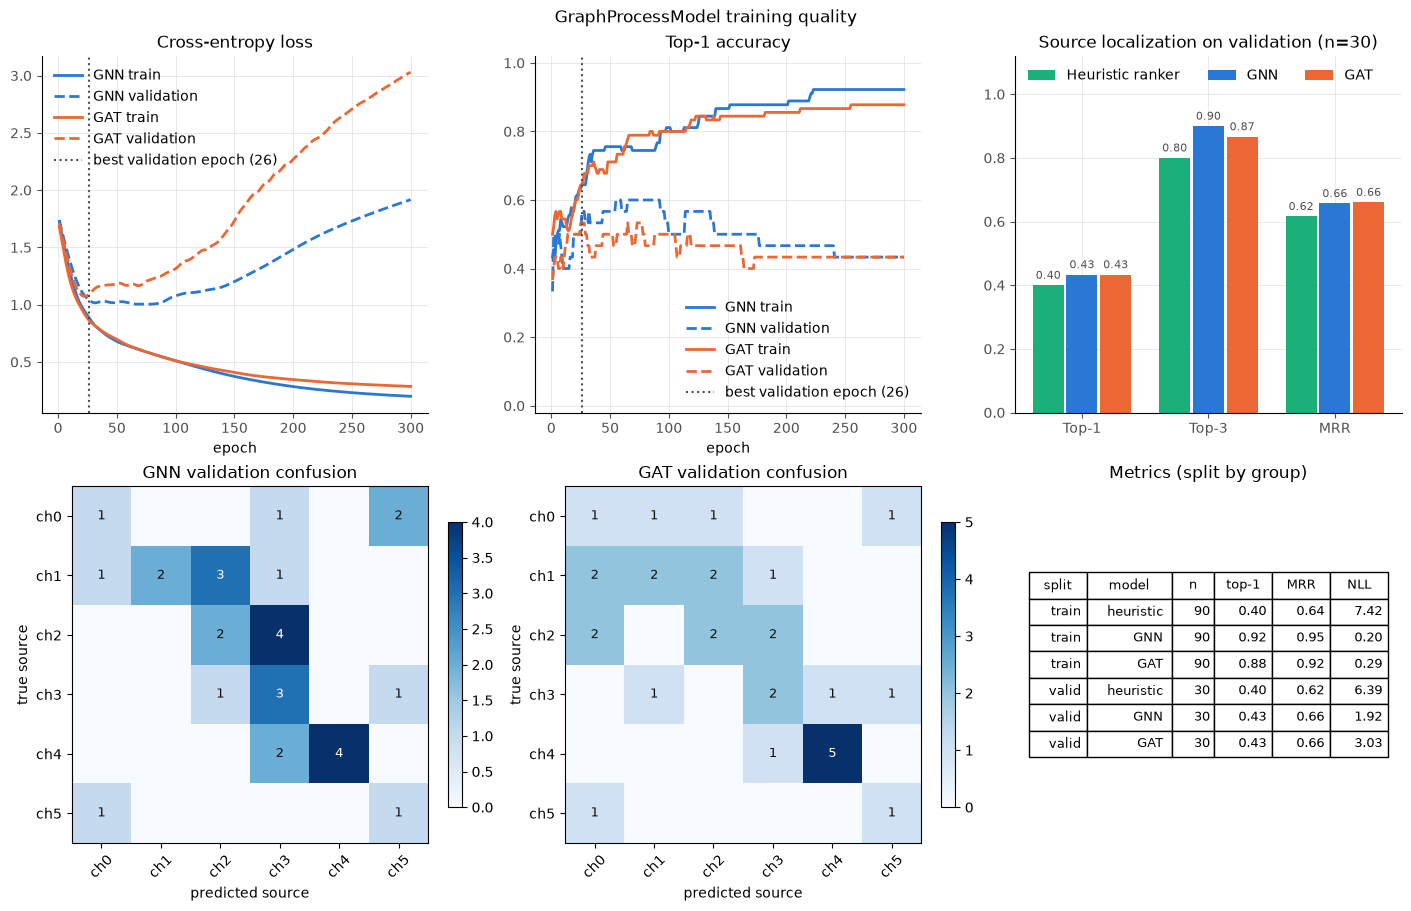

In [4]:
fig = viz.plot_training_report(report, channel_names=recordings['rec00'].channel_names)

## Early stopping from the learning curves

The dotted line marks `report.best_epoch`, the epoch with the lowest validation loss. Retraining
with that many epochs is a simple early-stopping rule. Strictly, choosing it on the validation
set makes validation optimistic – confirm the final choice on an untouched test set
(notebook 4).

In [5]:
print("best epoch:", report.best_epoch)
early = ProcessModelTrainer(
    GraphLearningConfig(hidden_dim=8, epochs=report.best_epoch, random_state=SEED),
    validation_fraction=0.25, random_state=SEED).train(manual)
pd.DataFrame(early.summary_table()).query("split == 'validation'").round(3)

best epoch: 26


,split,method,n,top1,top3,mrr,nll
3,validation,heuristic,30,0.400,0.8,0.616,6.390
4,validation,gnn,30,0.567,0.9,0.737,1.042
5,validation,gat,30,0.533,0.9,0.726,1.087


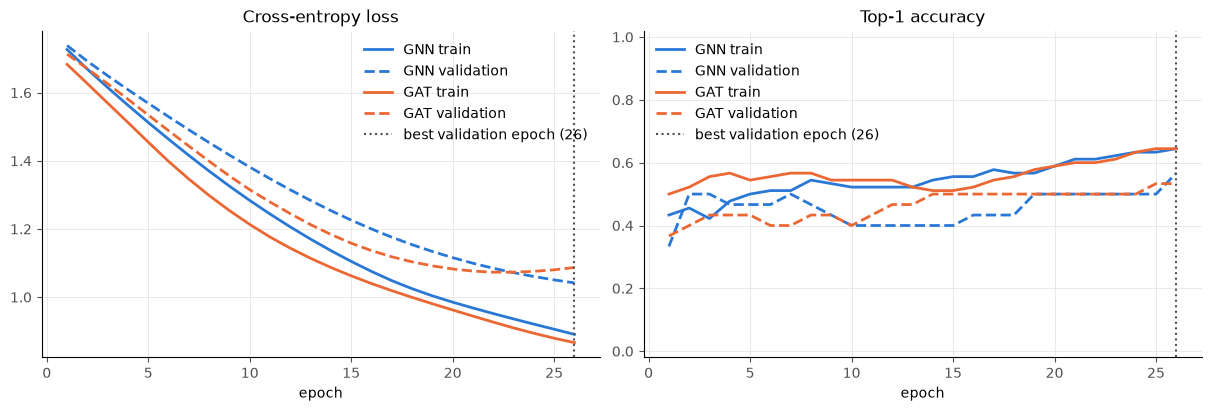

In [6]:
fig = viz.plot_training_history(early)

## Pseudo-labels: the teacher ceiling

Training on pseudo-labels and validating on **manual** labels shows the limitation stated in
notebook 2: the student learns to imitate the heuristic, so it cannot be expected to beat it.

In [7]:
pseudo_train = [e for e in pseudo.select() if e.series_id in {"rec00", "rec01", "rec02", "rec03",
                                                              "rec04", "rec05", "rec06", "rec07"}]
manual_val = [e.to_graph_episode() for e in manual.select()
              if e.series_id in {"rec08", "rec09", "rec10", "rec11"}]
pseudo_report = ProcessModelTrainer(GraphLearningConfig(epochs=300, random_state=SEED)).train(
    [e.to_graph_episode() for e in pseudo_train], validation=manual_val)
pd.DataFrame(pseudo_report.summary_table()).query("split == 'validation'").round(3)

,split,method,n,top1,top3,mrr,nll
3,validation,heuristic,40,0.3,0.800,0.568,9.472
4,validation,gnn,40,0.3,0.750,0.558,8.027
5,validation,gat,40,0.3,0.725,0.544,7.713


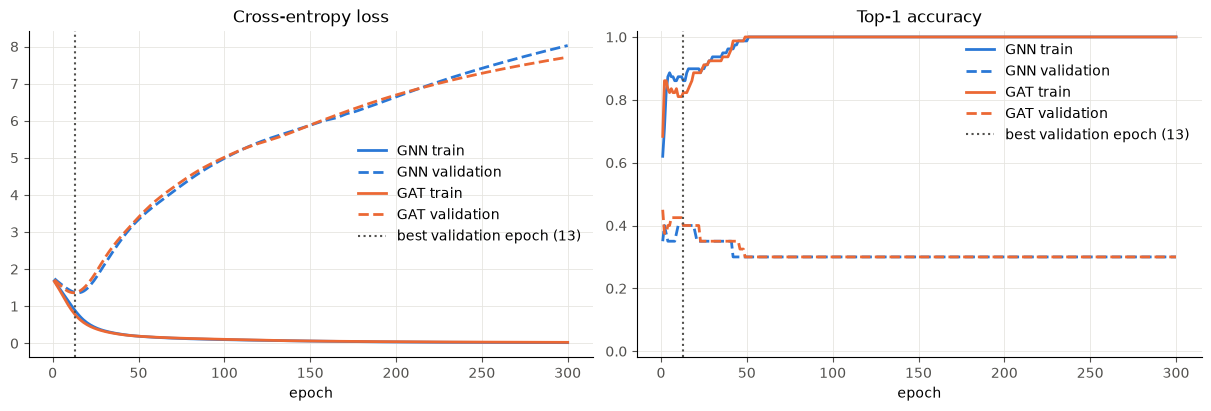

In [8]:
fig = viz.plot_training_history(pseudo_report)

## Use, inspect and save the trained model

true source: ch0 | heuristic: ch5 | GNN: ch5 | GAT: ch5


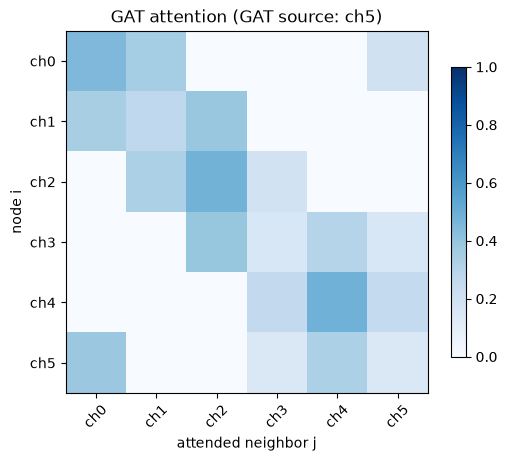

In [9]:
trained = GraphEVTPipeline(pipeline.evt_config, pipeline.graph_config, process_model=early.model)
episode = recordings["rec11"]
result = trained.run_detailed(TimeSeriesInput(episode.values[:700], channel_names=episode.channel_names))
names = episode.channel_names
print("true source:", names[episode.sources[0]],
      "| heuristic:", names[result.ranking.source],
      "| GNN:", names[result.process.gnn_source],
      "| GAT:", names[result.process.gat_source])
fig = viz.plot_attention(result.process, names)

In [10]:
early.model.save("graph_process_model.npz")
restored = GraphProcessModel.load("graph_process_model.npz")
np.allclose(restored.predict(result.ranking.features, result.graph.adjacency).gat_probabilities,
            result.process.gat_probabilities)

True

Attention is a learned predictive weight, **not** proof of physical direction or causation.
Continue with **04_evaluation_orchestration.ipynb**.